In [1]:
from getpass import getuser # Libaray to copy things
from pathlib import Path # Object oriented libary to deal with paths
import os
from tempfile import NamedTemporaryFile, TemporaryDirectory # Creating temporary Files/Dirs
from subprocess import run, PIPE
import sys
 
import dask # Distributed data libary
from dask_jobqueue import SLURMCluster # Setting up distributed memories via slurm
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources
import xarray as xr # Libary to work with labeled n-dimensional data and dask

In [2]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

# calculation
import metpy.calc as mpcalc

# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# basic
from pathlib import Path # Object oriented libary to deal with paths
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data
import glob
import os

#metpy
import metpy.calc as mpcalc
from metpy.units import units

## Load datasets

In [3]:
uas_ctl = xr.open_mfdataset('/scratch/m/m300948/test_04/surface_wind/ctl_uas_2020*',parallel=True, chunks={'time': -1, 'lat': -1, 'lon': -1})['uas']
uas_def = xr.open_mfdataset('/scratch/m/m300948/def_100/surface_wind/def_uas_2020*',parallel=True, chunks={'time': -1, 'lat': -1, 'lon': -1})['uas']

In [4]:
vas_ctl = xr.open_mfdataset('/scratch/m/m300948/test_04/surface_wind/ctl_vas_2020*',parallel=True,chunks={'time': -1, 'lat': -1, 'lon': -1})['vas']
vas_def = xr.open_mfdataset('/scratch/m/m300948/def_100/surface_wind/def_vas_2020*',parallel=True,chunks={'time': -1, 'lat': -1, 'lon': -1})['vas']

In [5]:
pr_ctl = xr.open_mfdataset('/scratch/m/m300948/test_04/pr/ctl_pr_2020*',parallel=True,chunks={'time': -1, 'lat': -1, 'lon': -1})['pr']
pr_def = xr.open_mfdataset('/scratch/m/m300948/def_100/pr/def_pr_2020*',parallel=True,chunks={'time': -1, 'lat': -1, 'lon': -1})['pr']

## Amazon masking

In [6]:
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES
ABinterp_biome = AMZ_BD.interp(latitude=pr_ctl.lat, longitude=pr_ctl.lon)

In [7]:
ua_ctl_mask = uas_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
ua_def_mask  = uas_def.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [8]:
va_ctl_mask = vas_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
va_def_mask  = vas_def.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [10]:
wind_ctl_mask = np.sqrt(ua_ctl_mask**2 + va_ctl_mask**2)
wind_def_mask = np.sqrt(ua_def_mask**2 + va_def_mask**2)

In [9]:
pr_ctl_mask = pr_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
pr_def_mask  = pr_def.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

## Extend the whole winds

In [ ]:
wind_ctl_hour_mask = (wind_ctl_mask.resample(time='H').mean()).compute()
wind_def_hour_mask = (wind_def_mask.resample(time='H').mean()).compute()

In [12]:
xarray_names = ['wind_ctl_mask','wind_def_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.isel(height=0).values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [13]:
wind_ctl_mask_f

array([0.       , 0.       , 0.       , ..., 1.4790374, 1.2644156,
       2.6339517], dtype=float32)

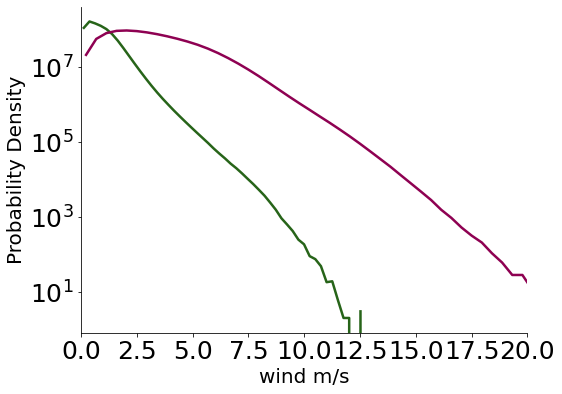

In [15]:
pdf_rainy_ctl, bins_rainy_ctl = np.histogram(wind_ctl_mask_f, bins=50, density=False)  # Adjust the number of bins as needed
pdf_rainy_def, bins_rainy_def = np.histogram(wind_def_mask_f, bins=50, density=False)

# Calculate the bin centers
bin_centers_rainy_ctl = (bins_rainy_ctl[:-1] + bins_rainy_ctl[1:]) / 2
bin_centers_rainy_def = (bins_rainy_def[:-1] + bins_rainy_def[1:]) / 2

# Plot the PDF
clr = ['darkkhaki', 'darkkhaki', 'darkkhaki', 'thistle', 'thistle', 'thistle'] 
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

# Plot the PDF
fig, ax = plt.subplots(figsize=(8,6))
plt.plot(bin_centers_rainy_ctl, pdf_rainy_ctl, label='CTL', color=right, linewidth=2.5)
plt.plot(bin_centers_rainy_def, pdf_rainy_def, label='DEF', color=left, linewidth=2.5)

# Set labels and title
plt.xlabel('wind m/s', fontsize='20')
plt.ylabel('Probability Density', fontsize='20')
#plt.title(title, fontsize='20')
plt.yscale('log')
plt.xlim(0, 20)

plt.xticks(fontsize=25,rotation=0)
plt.yticks(fontsize=25)

# add legend
#plt.legend(fontsize=20)
# remove top and right spines
ax.spines[['right', 'top']].set_visible(False)
# Display the plot
plt.show()

In [16]:
# Hourly rain
# Hourly mean
pr_ctl_mm_hour_mask = (pr_ctl_mask.resample(time='H').mean()*3600).compute()
pr_def_mm_hour_mask = (pr_def_mask.resample(time='H').mean()*3600).compute()
# select hours only the values above 50 mm/hour
pr_ctl_mm_hour_above50 = pr_ctl_mm_hour_mask.where(pr_ctl_mm_hour_mask > 50) # values
pr_def_mm_hour_above50 = pr_def_mm_hour_mask.where(pr_def_mm_hour_mask > 50)
intense_pr_mask_ctl = pr_ctl_mm_hour_mask > 50 # true/false
intense_pr_mask_def = pr_def_mm_hour_mask > 50 
# select only the values above 50 mm/hour
pr_ctl_mm_hour_below5 = pr_ctl_mm_hour_mask.where(pr_ctl_mm_hour_mask < 5) # values
pr_def_mm_hour_below5 = pr_def_mm_hour_mask.where(pr_def_mm_hour_mask < 5)
light_pr_mask_ctl = pr_ctl_mm_hour_mask < 5 # true/false
light_pr_mask_def = pr_def_mm_hour_mask < 5 

In [17]:
intense_pr_mask_ctl

<xarray.DataArray 'pr' (time: 8328, lat: 300, lon: 400)>
array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
...
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]])
Coordinates:
  * time       (time) datetime64[ns] 2020-01-20 ... 2020-12-31T23:00:00
  * lon        (lon) float64 -79.95 -79.85 -79.75 ... -40.25 -40.15 -40.05
  * lat        (lat) float64 -19.95 -19.85 -19.75 -19.65 ... 9.65 9.75 9.85 9.95
    latitude   (lat) float64 -19.95 -19.85 -19.75 -19.65 ... 9.65 9.75 9.85 9.95
    longitude  (lon) float64 -79.95 -79.85 -79.75 ... -40.25 -40.15 -40.05

In [19]:
wind_ctl_hour_mask = (wind_ctl_mask.resample(time='H').mean()).compute()

In [20]:
wind_def_hour_mask = (wind_def_mask.resample(time='H').mean()).compute()

In [ ]:
# intense wind
wind_intense_ctl_mask = wind_ctl_hour_mask.where(intense_pr_mask_ctl)
wind_intense_def_mask = wind_def_hour_mask.where(intense_pr_mask_def)

In [27]:
# light wind
wind_light_ctl_mask = wind_ctl_hour_mask.where(light_pr_mask_ctl)
wind_light_def_mask = wind_def_hour_mask.where(light_pr_mask_def)

In [28]:
xarray_names = ['wind_intense_ctl_mask','wind_intense_def_mask', 'wind_light_ctl_mask', 'wind_light_def_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.isel(height=0).values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

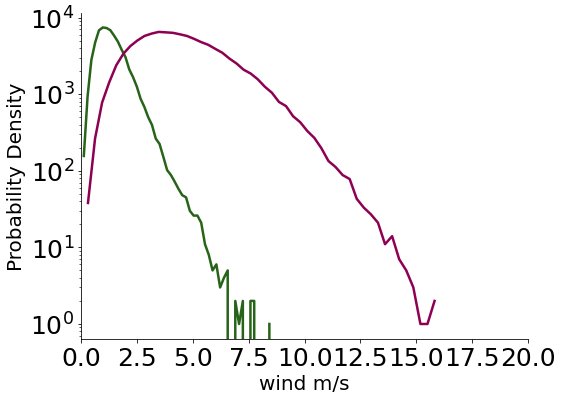

In [26]:
pdf_rainy_ctl, bins_rainy_ctl = np.histogram(wind_intense_ctl_mask_f, bins=50, density=False)  # Adjust the number of bins as needed
pdf_rainy_def, bins_rainy_def = np.histogram(wind_intense_def_mask_f, bins=50, density=False)

# Calculate the bin centers
bin_centers_rainy_ctl = (bins_rainy_ctl[:-1] + bins_rainy_ctl[1:]) / 2
bin_centers_rainy_def = (bins_rainy_def[:-1] + bins_rainy_def[1:]) / 2

# Plot the PDF
clr = ['darkkhaki', 'darkkhaki', 'darkkhaki', 'thistle', 'thistle', 'thistle'] 
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

# Plot the PDF
fig, ax = plt.subplots(figsize=(8,6))
plt.plot(bin_centers_rainy_ctl, pdf_rainy_ctl, label='CTL', color=right, linewidth=2.5)
plt.plot(bin_centers_rainy_def, pdf_rainy_def, label='DEF', color=left, linewidth=2.5)

# Set labels and title
plt.xlabel('wind m/s', fontsize='20')
plt.ylabel('Probability Density', fontsize='20')
#plt.title(title, fontsize='20')
plt.yscale('log')
plt.xlim(0, 20)

plt.xticks(fontsize=25,rotation=0)
plt.yticks(fontsize=25)

# add legend
#plt.legend(fontsize=20)
# remove top and right spines
ax.spines[['right', 'top']].set_visible(False)
# Display the plot
plt.show()

In [33]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def lighten_color(color, amount=0.5):
    """
    Lighten the given color by mixing it with white.
    
    Parameters:
        color (str or tuple): Matplotlib color name or RGB(A) tuple.
        amount (float): A value between 0 and 1 that determines how much to lighten the color.
                        0 returns the original color, while 1 returns white.
    
    Returns:
        tuple: The lightened color as an RGBA tuple.
    """
    try:
        c = mcolors.to_rgba(color)
    except ValueError:
        raise ValueError(f"Color {color} is not recognized")

    # Blend color with white (1, 1, 1)
    white = np.array([1, 1, 1, 1])
    new_color = c + (white - c) * amount
    return tuple(new_color)


In [34]:
# Example usage
lighter_right = lighten_color(right, amount=0.5)
lighter_left = lighten_color(left, amount=0.5)

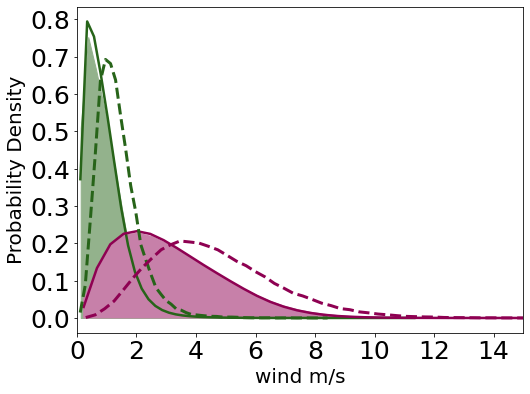

In [35]:
# Hourly mean precipitation 
# Total
pdf_ctl, bins_ctl = np.histogram(wind_ctl_mask_f, bins=50, density=True)  # Adjust the number of bins as needed
pdf_def, bins_def = np.histogram(wind_def_mask_f, bins=50, density=True)
# light
pdf_light_ctl, bins_light_ctl = np.histogram(wind_light_ctl_mask_f, bins=50, density=True)  # Adjust the number of bins as needed
pdf_light_def, bins_light_def = np.histogram(wind_light_def_mask_f, bins=50, density=True)
# violent
pdf_violent_ctl, bins_violent_ctl = np.histogram(wind_intense_ctl_mask_f, bins=50, density=True)  # Adjust the number of bins as needed
pdf_violent_def, bins_violent_def = np.histogram(wind_intense_def_mask_f, bins=50, density=True)

# Calculate the bin centers
bin_centers_ctl = (bins_ctl[:-1] + bins_ctl[1:]) / 2
bin_centers_def = (bins_def[:-1] + bins_def[1:]) / 2
bin_centers_light_ctl = (bins_light_ctl[:-1] + bins_light_ctl[1:]) / 2
bin_centers_light_def = (bins_light_def[:-1] + bins_light_def[1:]) / 2
bin_centers_violent_ctl = (bins_violent_ctl[:-1] + bins_violent_ctl[1:]) / 2
bin_centers_violent_def = (bins_violent_def[:-1] + bins_violent_def[1:]) / 2

# Plot the PDF
fig = plt.figure(figsize=(8, 6))
plt.fill_between(bin_centers_ctl, pdf_ctl, label='CTL', color=lighter_right)
plt.fill_between(bin_centers_def, pdf_def, label='DEF', color=lighter_left)
plt.plot(bin_centers_light_ctl, pdf_light_ctl, label='CTL_light', color=right, linewidth=2.5)
plt.plot(bin_centers_light_def, pdf_light_def, label='DEF_light', color=left, linewidth=2.5)
plt.plot(bin_centers_violent_ctl, pdf_violent_ctl, label='CTL_intense', color= right, linestyle='--', linewidth=3)
plt.plot(bin_centers_violent_def, pdf_violent_def, label='DEF_intense', color= left, linestyle='--', linewidth=3)

# Set labels and title
plt.xlabel('wind m/s', fontsize='20')
plt.ylabel('Probability Density', fontsize='20')
#plt.title(title, fontsize='20')
#plt.yscale('log')
plt.xlim(0, 15)

plt.xticks(fontsize=25,rotation=0)
plt.yticks(fontsize=25)

# add legend
#plt.legend(fontsize=20)

# Display the plot
plt.show() 

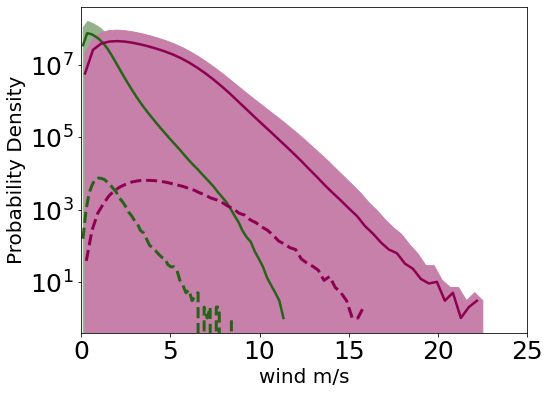

In [38]:
# Hourly mean precipitation 
# Total
pdf_ctl, bins_ctl = np.histogram(wind_ctl_mask_f, bins=50, density=False)  # Adjust the number of bins as needed
pdf_def, bins_def = np.histogram(wind_def_mask_f, bins=50, density=False)
# light
pdf_light_ctl, bins_light_ctl = np.histogram(wind_light_ctl_mask_f, bins=50, density=False)  # Adjust the number of bins as needed
pdf_light_def, bins_light_def = np.histogram(wind_light_def_mask_f, bins=50, density=False)
# violent
pdf_violent_ctl, bins_violent_ctl = np.histogram(wind_intense_ctl_mask_f, bins=50, density=False)  # Adjust the number of bins as needed
pdf_violent_def, bins_violent_def = np.histogram(wind_intense_def_mask_f, bins=50, density=False)

# Calculate the bin centers
bin_centers_ctl = (bins_ctl[:-1] + bins_ctl[1:]) / 2
bin_centers_def = (bins_def[:-1] + bins_def[1:]) / 2
bin_centers_light_ctl = (bins_light_ctl[:-1] + bins_light_ctl[1:]) / 2
bin_centers_light_def = (bins_light_def[:-1] + bins_light_def[1:]) / 2
bin_centers_violent_ctl = (bins_violent_ctl[:-1] + bins_violent_ctl[1:]) / 2
bin_centers_violent_def = (bins_violent_def[:-1] + bins_violent_def[1:]) / 2

# Plot the PDF
fig = plt.figure(figsize=(8, 6))
plt.fill_between(bin_centers_ctl, pdf_ctl, label='CTL', color=lighter_right)
plt.fill_between(bin_centers_def, pdf_def, label='DEF', color=lighter_left)
plt.plot(bin_centers_light_ctl, pdf_light_ctl, label='CTL_light', color=right, linewidth=2.5)
plt.plot(bin_centers_light_def, pdf_light_def, label='DEF_light', color=left, linewidth=2.5)
plt.plot(bin_centers_violent_ctl, pdf_violent_ctl, label='CTL_intense', color= right, linestyle='--', linewidth=3)
plt.plot(bin_centers_violent_def, pdf_violent_def, label='DEF_intense', color= left, linestyle='--', linewidth=3)

# Set labels and title
plt.xlabel('wind m/s', fontsize='20')
plt.ylabel('Probability Density', fontsize='20')
#plt.title(title, fontsize='20')
plt.yscale('log')
plt.xlim(0, 25)

plt.xticks(fontsize=25,rotation=0)
plt.yticks(fontsize=25)

# add legend
#plt.legend(fontsize=20)

# Display the plot
plt.show() 